# Tuition Comparisons: Australia, United Kingdom, and New Zealand

This notebook documents the structural differences in how domestic undergraduate tuition fees are set and changed in Australia, the United Kingdom, and New Zealand over the 2016–2024 study window. The comparison has a specific purpose: the DiD analysis uses UK and NZ as control countries against Australia. For that design to produce valid estimates, the control countries must not have experienced their own discipline-specific fee reforms during the study period. This notebook establishes that condition and discusses how cross-country fee differences do — and do not — affect the DiD estimates.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

fund = pd.read_csv(ROOT / 'data' / 'clean' / 'AnnualFundingAUS2019-2026_with_category_key.csv')

PRIORITY   = [1, 2, 3, 4, 5, 6, 7]
NONPRIORITY = [8, 9, 10]

CAT_NAMES = {
    1: 'Natural & Physical Science',
    2: 'Information Technology',
    3: 'Engineering & Related Tech',
    4: 'Architecture & Building',
    5: 'Environment & Related',
    6: 'Health',
    7: 'Education',
    8: 'Management & Commerce',
    9: 'Society & Culture',
   10: 'Creative Arts',
}

# AUS mean student contribution by category and year (2019-2024)
aus_fee = (
    fund[fund['Year'].between(2019, 2024)]
    .groupby(['CategoryKey', 'Category', 'Year'])['MaximumStudentContribution']
    .mean().round(0).reset_index()
)
aus_fee = aus_fee[aus_fee['CategoryKey'].isin(range(1, 11))].copy()

# AUS mean commonwealth contribution by category and year
aus_cw = (
    fund[fund['Year'].between(2019, 2024)]
    .groupby(['CategoryKey', 'Category', 'Year'])['CommonwealthContribution']
    .mean().round(0).reset_index()
)
aus_cw = aus_cw[aus_cw['CategoryKey'].isin(range(1, 11))].copy()

# UK: flat domestic fee cap (England/Wales), academic years mapped to calendar years
# £9,000 cap from 2012; raised to £9,250 from 2017-18; frozen thereafter
# Using 2022 midpoint GBP/AUD exchange rate ~1.76 for illustration
GBP_TO_AUD = 1.76
NZD_TO_AUD = 0.90

uk_fee_gbp = {yr: (9000 if yr <= 2016 else 9250) for yr in range(2016, 2025)}
uk_fee_aud = {yr: round(v * GBP_TO_AUD) for yr, v in uk_fee_gbp.items()}

# NZ: government sets Maximum Student Contribution bands; no JRG-equivalent
# Typical domestic bachelor range NZD $5,500-$9,500; approximate midpoint ~$7,200
# Fees Free policy (2018-): first year of study fully subsidised for eligible domestic students
nz_fee_low_nzd  = 5500
nz_fee_high_nzd = 9500
nz_fee_mid_aud  = round((nz_fee_low_nzd + nz_fee_high_nzd) / 2 * NZD_TO_AUD)

print('Setup complete.')
print(f'UK cap (GBP): £9,250  →  AUD equiv. ~${uk_fee_aud[2022]:,} at 2022 exchange rates')
print(f'NZ midpoint (NZD): ~${(nz_fee_low_nzd+nz_fee_high_nzd)//2:,}  →  AUD equiv. ~${nz_fee_mid_aud:,}')

Setup complete.
UK cap (GBP): £9,250  →  AUD equiv. ~$16,280 at 2022 exchange rates
NZ midpoint (NZD): ~$7,500  →  AUD equiv. ~$6,750


## 1. System Architecture

The three countries use structurally different mechanisms to set domestic undergraduate fees.

| Feature | Australia | United Kingdom (England/Wales) | New Zealand |
|---------|-----------|-------------------------------|-------------|
| Fee-setting mechanism | Government sets **funding clusters**; each FOE assigned to a cluster that determines the student contribution maximum | Government sets a single **fee cap** (£9,250/year); universities charge up to the cap for all undergraduate degrees | Government sets **Maximum Student Contribution** bands; universities set within the cap |
| Discipline variation | **Yes** — student contribution varies significantly by field (e.g., Education ~$4,000 vs. M&C ~$15,000 post-JRG) | **No** — the cap is identical across all subjects | **Minimal** — some variation by programme type but no subject-cluster system |
| Government co-contribution | **Yes** — Commonwealth Contribution supplements student fee to meet total EFTSL cost | **No** — universities receive tuition revenue solely from student fees (+ grants for some activities) | **Yes** — Tertiary Education Commission (TEC) subsidises via Student Achievement Component (SAC) funding |
| Major reforms 2016–2024 | **JRG (2021)** — realigned funding clusters, cutting fees for priority disciplines and raising them for non-priority disciplines | **Frozen** — £9,250 cap unchanged from 2017-18; no discipline-specific reform | **Fees Free (2018)** — first year of domestic undergraduate study fully subsidised; universal, not discipline-specific |
| Loan scheme | HECS-HELP: income-contingent, no interest (CPI-indexed), repaid via ATO | Student Loans (Plan 2/5): income-contingent, low interest, repaid via HMRC | Student Loan Scheme: interest-free for NZ residents, income-contingent repayment |
| Scotland/Wales note | N/A | Scotland: free for Scottish-domiciled students; Wales: partly subsidised | N/A |

### Australia: JRG Cluster Reassignment

The JRG took effect in 2021 and moved disciplines between funding clusters, creating sharp fee changes that were discipline-specific. Priority fields (education, nursing, IT, engineering, agriculture) received fee cuts; non-priority fields (business, law, arts, humanities) received increases. Because this reform was uniquely Australian and targeted specific fields, it is the treatment in the DiD.

### UK: No Comparable Reform

England raised the fee cap from £9,000 to £9,250 in 2017-18. This was a uniform aggregate increase (all subjects simultaneously, by the same amount) with no discipline-specific component. No further changes were made through 2024. The flat cap means UK enrollment variation by discipline during 2016–2024 reflects demand and supply factors entirely, not fee incentives — making it a clean control.

### New Zealand: Fees Free (2018)

NZ introduced Fees Free in January 2018: the first year (and later the first 200 hours or $12,000 of fees, whichever came first) of domestic tertiary study was fully subsidised for eligible students. This was a universal policy affecting all disciplines equally. Its timing (2018, three years before JRG) means it falls in the pre-treatment period for the DiD and is absorbed by the year fixed effects. It does not create differential discipline effects.

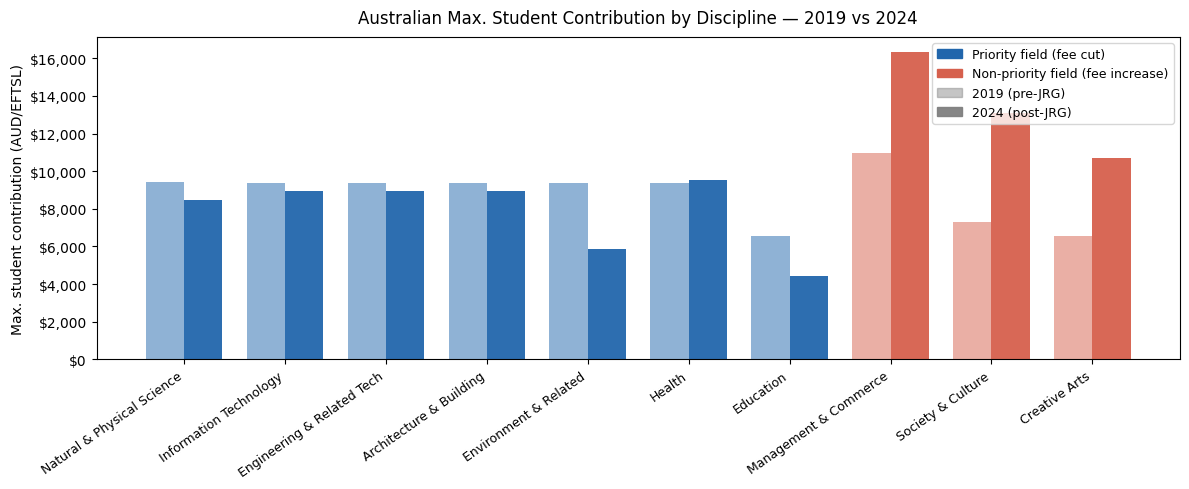

In [2]:
# AUS student contribution by category: 2019 vs 2024
pre  = aus_fee[aus_fee['Year'] == 2019].set_index('CategoryKey')['MaximumStudentContribution']
post = aus_fee[aus_fee['Year'] == 2024].set_index('CategoryKey')['MaximumStudentContribution']

keys   = sorted(pre.index)
labels = [CAT_NAMES[k] for k in keys]
x      = np.arange(len(keys))
w      = 0.38

priority_color    = '#2166ac'
nonpriority_color = '#d6604d'

fig, ax = plt.subplots(figsize=(12, 5))
for i, k in enumerate(keys):
    col = priority_color if k in PRIORITY else nonpriority_color
    ax.bar(x[i] - w/2, pre[k],  w, color=col, alpha=0.50, label='_')
    ax.bar(x[i] + w/2, post[k], w, color=col, alpha=0.95, label='_')

# Custom legend
p1 = mpatches.Patch(color=priority_color,    label='Priority field (fee cut)')
p2 = mpatches.Patch(color=nonpriority_color, label='Non-priority field (fee increase)')
pre_patch  = mpatches.Patch(color='grey', alpha=0.45, label='2019 (pre-JRG)')
post_patch = mpatches.Patch(color='grey', alpha=0.95, label='2024 (post-JRG)')
ax.legend(handles=[p1, p2, pre_patch, post_patch], fontsize=9, loc='upper right')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_ylabel('Max. student contribution (AUD/EFTSL)', fontsize=10)
ax.set_title('Australian Max. Student Contribution by Discipline — 2019 vs 2024', fontsize=12, pad=10)
ax.axhline(0, color='black', linewidth=0.6)
plt.tight_layout()
plt.show()

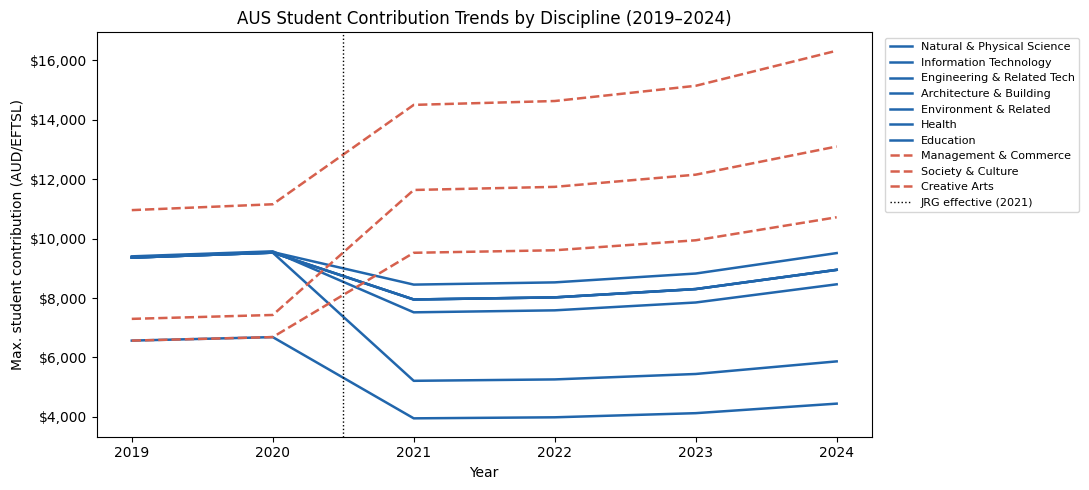

In [3]:
# AUS student contribution trend 2019-2024 for each category
fig, ax = plt.subplots(figsize=(11, 5))
for k in sorted(CAT_NAMES.keys()):
    sub  = aus_fee[aus_fee['CategoryKey'] == k].sort_values('Year')
    col  = '#2166ac' if k in PRIORITY else '#d6604d'
    lsyl = '-'        if k in PRIORITY else '--'
    ax.plot(sub['Year'], sub['MaximumStudentContribution'], lsyl,
            color=col, linewidth=1.8,
            label=CAT_NAMES[k])

ax.axvline(2020.5, color='black', linewidth=1.0, linestyle=':', label='JRG effective (2021)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_xticks(range(2019, 2025))
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Max. student contribution (AUD/EFTSL)', fontsize=10)
ax.set_title('AUS Student Contribution Trends by Discipline (2019–2024)', fontsize=12)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

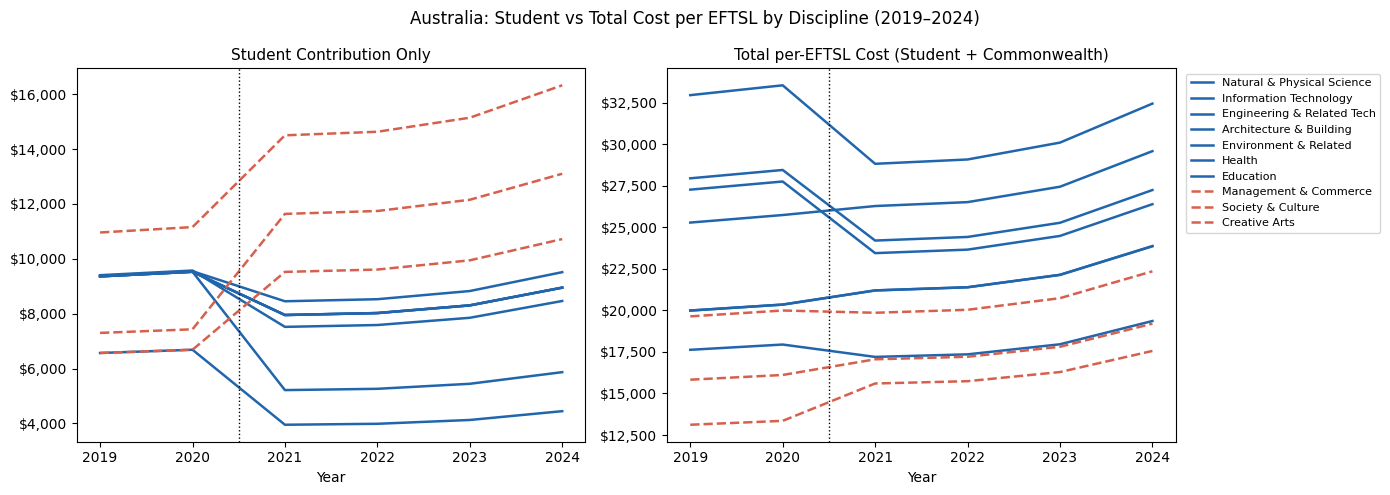

In [4]:
# Total cost (student + Commonwealth) per EFTSL — shows government offsets JRG cuts for priority fields
aus_total = aus_fee.merge(
    aus_cw[['CategoryKey', 'Year', 'CommonwealthContribution']],
    on=['CategoryKey', 'Year']
)
aus_total['TotalCost'] = aus_total['MaximumStudentContribution'] + aus_total['CommonwealthContribution']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for k in sorted(CAT_NAMES.keys()):
    sub = aus_total[aus_total['CategoryKey'] == k].sort_values('Year')
    col = '#2166ac' if k in PRIORITY else '#d6604d'
    ls  = '-'       if k in PRIORITY else '--'
    axes[0].plot(sub['Year'], sub['MaximumStudentContribution'], ls,
                 color=col, linewidth=1.8, label=CAT_NAMES[k])
    axes[1].plot(sub['Year'], sub['TotalCost'], ls,
                 color=col, linewidth=1.8, label=CAT_NAMES[k])

for ax in axes:
    ax.axvline(2020.5, color='black', linewidth=1.0, linestyle=':')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    ax.set_xticks(range(2019, 2025))
    ax.set_xlabel('Year', fontsize=10)

axes[0].set_title('Student Contribution Only', fontsize=11)
axes[1].set_title('Total per-EFTSL Cost (Student + Commonwealth)', fontsize=11)
axes[1].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

fig.suptitle('Australia: Student vs Total Cost per EFTSL by Discipline (2019–2024)', fontsize=12)
plt.tight_layout()
plt.show()

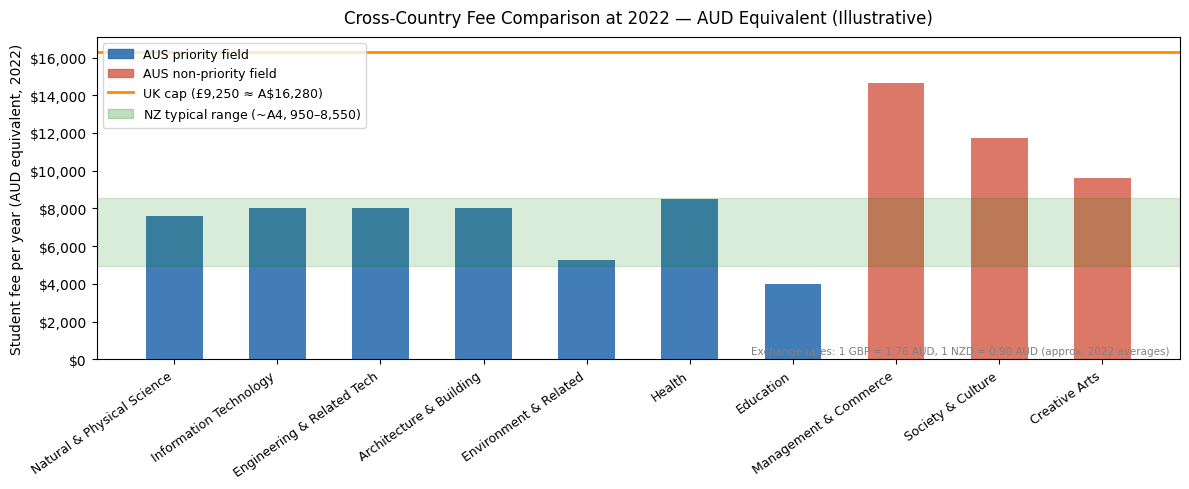

In [5]:
# Cross-country fee comparison at a single year (2022) in AUD equivalent
# AUS: student contribution only (what the student actually pays)
aus_2022 = aus_fee[aus_fee['Year'] == 2022].set_index('CategoryKey')['MaximumStudentContribution']

# UK: uniform £9,250 for all subjects; converted at 2022 GBP/AUD ~1.76
uk_2022_aud = 9250 * GBP_TO_AUD

# NZ: mid-range estimate; converted at 2022 NZD/AUD ~0.90
nz_low_aud  = nz_fee_low_nzd  * NZD_TO_AUD
nz_high_aud = nz_fee_high_nzd * NZD_TO_AUD

keys   = sorted(aus_2022.index)
labels = [CAT_NAMES[k] for k in keys]
x      = np.arange(len(keys))

fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = [('#2166ac' if k in PRIORITY else '#d6604d') for k in keys]
bars = ax.bar(x, [aus_2022[k] for k in keys], 0.55,
              color=bar_colors, alpha=0.85, label='AUS student contribution')

# UK flat line
ax.axhline(uk_2022_aud, color='darkorange', linewidth=2.0,
           linestyle='-', label=f'UK cap (£9,250 ≈ A${uk_2022_aud:,.0f})')

# NZ band
ax.axhspan(nz_low_aud, nz_high_aud, alpha=0.15, color='green',
           label=f'NZ typical range (~A${nz_low_aud:,.0f}–${nz_high_aud:,.0f})')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_ylabel('Student fee per year (AUD equivalent, 2022)', fontsize=10)
ax.set_title('Cross-Country Fee Comparison at 2022 — AUD Equivalent (Illustrative)', fontsize=12, pad=10)

p1 = mpatches.Patch(color='#2166ac', alpha=0.85, label='AUS priority field')
p2 = mpatches.Patch(color='#d6604d', alpha=0.85, label='AUS non-priority field')
uk_line = plt.Line2D([0], [0], color='darkorange', linewidth=2,
                     label=f'UK cap (£9,250 ≈ A${uk_2022_aud:,.0f})')
nz_patch = mpatches.Patch(color='green', alpha=0.25,
                           label=f'NZ typical range (~A${int(nz_low_aud):,}–${int(nz_high_aud):,})')
ax.legend(handles=[p1, p2, uk_line, nz_patch], fontsize=9, loc='upper left')
ax.set_ylim(bottom=0)

ax.annotate('Exchange rates: 1 GBP = 1.76 AUD, 1 NZD = 0.90 AUD (approx. 2022 averages)',
            xy=(0.99, 0.01), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=7.5, color='gray')

plt.tight_layout()
plt.show()

## 2. Key Comparisons

### Fee levels

At 2022 exchange rates, the UK fee cap (£9,250 ≈ AUD $16,280) sits above every Australian student contribution except Management & Commerce and Society & Culture (the highest non-priority fields). NZ fees fall in a lower band (roughly AUD $5,000–$8,500) that overlaps with Australian priority fields after JRG.

These absolute differences do not affect the DiD estimates: the TWFE model includes country fixed effects, which absorb all time-invariant cross-country level differences in fees and enrollment scales.

### JRG fee divergence within Australia

The left panel of the dual-panel chart illustrates the key treatment variation. Before 2021, student contributions across all categories clustered tightly between roughly $6,500 and $11,000. After JRG the spread widened dramatically: priority fields (blue) fell to $4,000–$9,500 while non-priority fields (red) rose to $11,500–$16,500. This cross-category divergence within Australia is what the DiD attempts to detect in enrollment responses.

### Total cost vs student contribution

The right panel (student + Commonwealth contribution) shows that total per-EFTSL costs changed far less dramatically than student contributions alone. For priority fields, the Commonwealth increased its contribution to offset the student-side cut, keeping university revenue roughly stable. For non-priority fields the Commonwealth contribution fell as the student contribution rose. This means the JRG primarily shifted who pays — from the government toward the student for non-priority fields, and from the student toward the government for priority fields — without dramatically changing the total resources available to teach those subjects.

### UK: discipline-blind fees strengthen the control

Because UK fees are identical across all subjects, any differential enrollment trend in the UK between disciplines reflects demand, graduate outcomes, or demographic factors — not price signals. This makes UK enrollment trends a cleaner counterfactual for Australia's discipline-level enrollment responses than a country that also had discipline-specific fee variation.

### NZ: Fees Free is a valid control

The NZ Fees Free policy (effective 2018) introduced a universal fee subsidy for all domestic students in their first year, regardless of discipline. Because it applies uniformly to all disciplines, it cannot explain differential enrollment shifts toward or away from specific fields. It therefore does not violate the parallel trends assumption at the discipline level. Its timing (2018) places it fully in the pre-treatment window.

## 3. Implications for DiD Validity

The table below summarises the key conditions for DiD validity and how each country's fee structure relates to each condition.

| Condition | Requirement | Australia (treated) | UK (control) | NZ (control) |
|-----------|-------------|--------------------|--------------|--------------|
| No confounding fee reform in control | Controls must not have had their own discipline-specific fee changes during 2021–2024 | N/A (treated) | Met — no reform after 2017-18 | Met — Fees Free is universal and pre-treatment |
| Parallel trends (pre-treatment) | Treated and control must follow parallel enrollment trends before 2021 | Tested via event study | Trend data available 2016–2020 | Trend data available 2016–2020 |
| Country-level fee levels | Absorbed by country fixed effects | Absorbed | Absorbed | Absorbed |
| Aggregate time shocks | Absorbed by year fixed effects | COVID, inflation | COVID, Brexit | COVID, Fees Free |
| Discipline-specific demand shocks | Not absorbed — potential confound | Possible (e.g., tech boom) | Same shocks weaken the confound argument | Same shocks weaken the confound argument |

### Caveat: price elasticity differences

One structural difference that the DiD cannot fully resolve is that UK and NZ students may have different price elasticities of demand for higher education. If UK/NZ students are systematically less responsive to fees (e.g., because loan repayment is easier or fees are less salient), then UK/NZ enrollment trends may understate the demand response that would occur in Australia even without the JRG. However, this is a level effect on responsiveness, not a discipline-specific bias — it would affect all fields equally and would bias the overall DiD coefficient, not the relative magnitude across disciplines. The cross-discipline ranking of DiD coefficients (which fields responded most) is unlikely to be affected by this elasticity difference.